# 05 - Algorithm 2: Double Q-learning

The second algorithm is *model-free*: it never sees the transition kernel and learns only
from sampled seasons. That is the realistic setting - a hotel does not know its own demand
distribution - and it is why the comparison against notebook 04's exact optimum is
informative rather than circular.

Two design choices matter and both are justified empirically below.

**Double Q-learning.** Standard Q-learning bootstraps from `max_a Q(s', a)`, and the
maximum of noisy estimates is biased upward. With Poisson rewards of order 10^4 per step
that optimism is severe. Double Q-learning (van Hasselt, 2010) keeps two tables, using one
to *select* the greedy action and the other to *evaluate* it.

**n-step returns.** The agent sees occupancy only as a decile bin, so its state is an
aggregation of the true one and the Markov property fails. Under aggregation, one-step
bootstrapping compounds the error at every backup. Replacing bootstrapped values with
observed reward removes that compounding, and at `n = H` the target is the full
Monte-Carlo return.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour
use_style()

import joblib
from config import MULTIPLIERS, HORIZON, N_OCC_BINS, N_REGIMES, REGIME_NAMES, RESULTS
from environment import HotelPricingEnv
from agents import train_double_q, greedy_value, policy_table, fine_policy
import mdp

env = HotelPricingEnv("City Hotel", "May", seed=0)
V_STAR = joblib.load(RESULTS / "vi_solution.joblib")["V_star"]

# Room count at the centre of each occupancy bin, used whenever a bin-level
# quantity has to be compared against the full-resolution one.
occ_centres = ((np.arange(N_OCC_BINS) + 0.5) / N_OCC_BINS * env.capacity).astype(int)
week_rows = [HORIZON - w for w in range(HORIZON)]

print(f"agent state space: {env.n_states} -> "
      f"{np.prod(env.n_states) * env.n_actions:,} Q-values")
print(f"target to beat   : V* = {V_STAR:,.0f} (from notebook 04)")

agent state space: (13, 10, 3) -> 2,340 Q-values
target to beat   : V* = 528,836 (from notebook 04)


## 1. Why n-step returns are necessary

An ablation over `n`, three seeds each. One-step Double Q-learning plateaus around 93% of
the optimum and swings several points between seeds; the Monte-Carlo return reaches ~99%
and is stable. This is the behaviour Sutton & Barto predict for bootstrapping under state
aggregation, and it is the reason `n_step = HORIZON` is the default.

In [2]:
ablation = []
for n_step in [1, 3, HORIZON]:
    values = []
    for seed in range(3):
        q, _, _ = train_double_q(env, episodes=60_000, n_step=n_step, seed=seed)
        values.append(greedy_value(env, q, n_episodes=1500))
    ablation.append({"n_step": n_step, "mean": np.mean(values), "std": np.std(values),
                     "pct_of_V*": 100 * np.mean(values) / V_STAR})
ablation = pd.DataFrame(ablation).set_index("n_step")
ablation.round(1)

,mean,std,pct_of_V*
n_step,,,
1,490379.9,2371.5,92.7
3,503889.5,1616.1,95.3
12,521207.1,1474.6,98.6


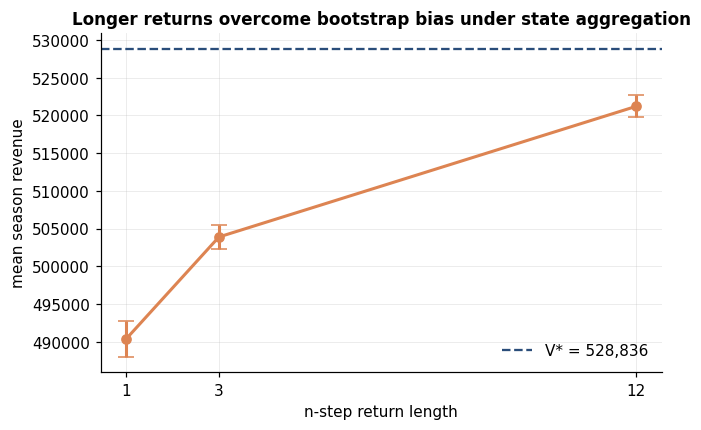

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.errorbar(ablation.index, ablation["mean"], yerr=ablation["std"], marker="o",
            capsize=5, lw=2, color="#dd8452")
ax.axhline(V_STAR, color="#2a4d7a", ls="--", lw=1.5, label=f"V* = {V_STAR:,.0f}")
ax.set(xlabel="n-step return length", ylabel="mean season revenue",
       title="Longer returns overcome bootstrap bias under state aggregation",
       xticks=ablation.index)
ax.legend()
save_fig("05_nstep_ablation")
plt.show()

## 2. Training

Five seeds, 100,000 episodes each, with the greedy policy evaluated periodically so
progress toward `V*` can be plotted rather than inferred from the noisy training return.

In [4]:
runs = []
for seed in range(5):
    q, history, checkpoints = train_double_q(
        env, episodes=100_000, seed=seed, eval_every=10_000, eval_episodes=600)
    runs.append({"seed": seed, "q": q, "history": history, "checkpoints": checkpoints})
    print(f"seed {seed}: final greedy value {checkpoints[-1][1]:>9,.0f} "
          f"({100 * checkpoints[-1][1] / V_STAR:.1f}% of V*)")

finals = np.array([r["checkpoints"][-1][1] for r in runs])
print(f"\nacross seeds: {finals.mean():,.0f} +/- {finals.std():,.0f} "
      f"({100 * finals.mean() / V_STAR:.1f}% of V*)")
best_run = runs[int(np.argmax(finals))]
Q = best_run["q"]

seed 0: final greedy value   522,000 (98.7% of V*)


seed 1: final greedy value   523,015 (98.9% of V*)


seed 2: final greedy value   520,821 (98.5% of V*)


seed 3: final greedy value   523,991 (99.1% of V*)


seed 4: final greedy value   524,572 (99.2% of V*)

across seeds: 522,880 +/- 1,351 (98.9% of V*)


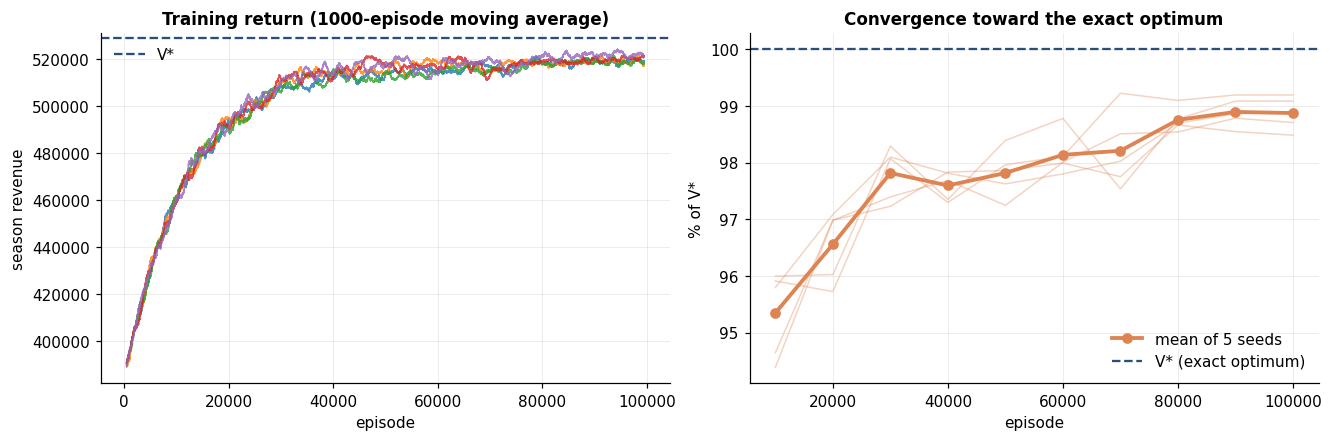

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))

window = 1000
for r in runs:
    smooth = np.convolve(r["history"], np.ones(window) / window, mode="valid")
    axes[0].plot(np.arange(len(smooth)) + window // 2, smooth, lw=1, alpha=0.8)
axes[0].axhline(V_STAR, color="#2a4d7a", ls="--", lw=1.5, label="V*")
axes[0].set(xlabel="episode", ylabel="season revenue",
            title=f"Training return ({window}-episode moving average)")
axes[0].legend()

episodes = [c[0] for c in runs[0]["checkpoints"]]
curves = np.array([[c[1] for c in r["checkpoints"]] for r in runs])
axes[1].plot(episodes, 100 * curves.T / V_STAR, color="#dd8452", alpha=0.35, lw=1)
axes[1].plot(episodes, 100 * curves.mean(axis=0) / V_STAR, color="#dd8452", lw=2.5,
             marker="o", label="mean of 5 seeds")
axes[1].axhline(100, color="#2a4d7a", ls="--", lw=1.5, label="V* (exact optimum)")
axes[1].set(xlabel="episode", ylabel="% of V*", title="Convergence toward the exact optimum")
axes[1].legend()
save_fig("05_training")
plt.show()

## 3. Exact value of the learned policy

Monte-Carlo evaluation carries sampling noise. Because the learned policy is a function of
the occupancy bin, it can be expanded to the unabstracted state space and valued
*exactly* by one backward pass - no simulation error at all. The two agree, which
validates both.

In [6]:
mc_value = greedy_value(env, Q, n_episodes=3000)
exact_value = mdp.optimal_value(env, mdp.policy_evaluation(env, fine_policy(Q, env)))

print(f"Monte-Carlo estimate : {mc_value:>10,.0f}")
print(f"exact policy value   : {exact_value:>10,.0f}")
print(f"exact optimum V*     : {V_STAR:>10,.0f}")
print(f"\ntotal optimality gap: {100 * (1 - exact_value / V_STAR):.2f}%")

Monte-Carlo estimate :    525,321
exact policy value   :    524,953
exact optimum V*     :    528,836

total optimality gap: 0.73%


That gap has two separable causes, and it is worth knowing which dominates. Some of it is
**discretisation**: no policy that sees occupancy only as a decile can match one that sees
the exact room count. The rest is **learning error**: the agent has not perfectly found the
best policy available within its own state representation.

The discretisation ceiling is measurable. Projecting the exact optimal policy onto the bin
grid - evaluating it at each bin's midpoint - gives the best a decile-resolution policy could
plausibly do, and `mdp.policy_evaluation` values it exactly.

In [7]:
pi_star_full = np.load(RESULTS / "vi_policy.npy")
sold_levels = np.arange(env.capacity + 1)
bin_of = np.minimum((sold_levels / env.capacity * N_OCC_BINS).astype(int), N_OCC_BINS - 1)

projected = np.empty((HORIZON, env.capacity + 1, N_REGIMES), dtype=np.int8)
for w in range(HORIZON):
    projected[w] = pi_star_full[w][occ_centres][bin_of]
ceiling = mdp.optimal_value(env, mdp.policy_evaluation(env, projected))

print(f"exact optimum, full inventory state : {V_STAR:>10,.0f}   100.00%")
print(f"best decile-resolution policy       : {ceiling:>10,.0f}   {100 * ceiling / V_STAR:6.2f}%")
print(f"policy learned from experience      : {exact_value:>10,.0f}   {100 * exact_value / V_STAR:6.2f}%")
print(f"\n  cost of the state abstraction : {100 * (1 - ceiling / V_STAR):.2f}%")
print(f"  residual learning error       : {100 * (ceiling - exact_value) / V_STAR:.2f}%")

exact optimum, full inventory state :    528,836   100.00%
best decile-resolution policy       :    527,154    99.68%
policy learned from experience      :    524,953    99.27%

  cost of the state abstraction : 0.32%
  residual learning error       : 0.42%


## 4. The learned policy

Compared side by side with the exact optimum from notebook 04, the learned policy reproduces
the same broad structure - protect rate when ahead of pace, discount late when rooms remain -
but visibly more raggedly.

**Grey cells are states the agent never reached.** A model-free learner only knows what it
has experienced, and much of this grid is unreachable: the hotel cannot be 80% full in week 1,
nor nearly empty in week 11. Value Iteration fills those cells in because it evaluates the
model everywhere, but they are decisions that will never be taken.

The agreement statistics below are worth dwelling on, because they look contradictory at
first. The learned policy picks a *different* action from the optimum in most reachable
states, yet gives up under 1% of the value. Both can be true because the action-value surface
is flat over wide regions: at the start of the season the six actions are within 3% of each
other in `Q*`, so choosing 1.30x where the optimum says 1.45x costs almost nothing. The
decisions that matter are concentrated in the late, high-occupancy states - and those are
exactly the ones the agent visits most and gets right. A policy heat map therefore *overstates*
disagreement; only the value function says how much a difference is worth.

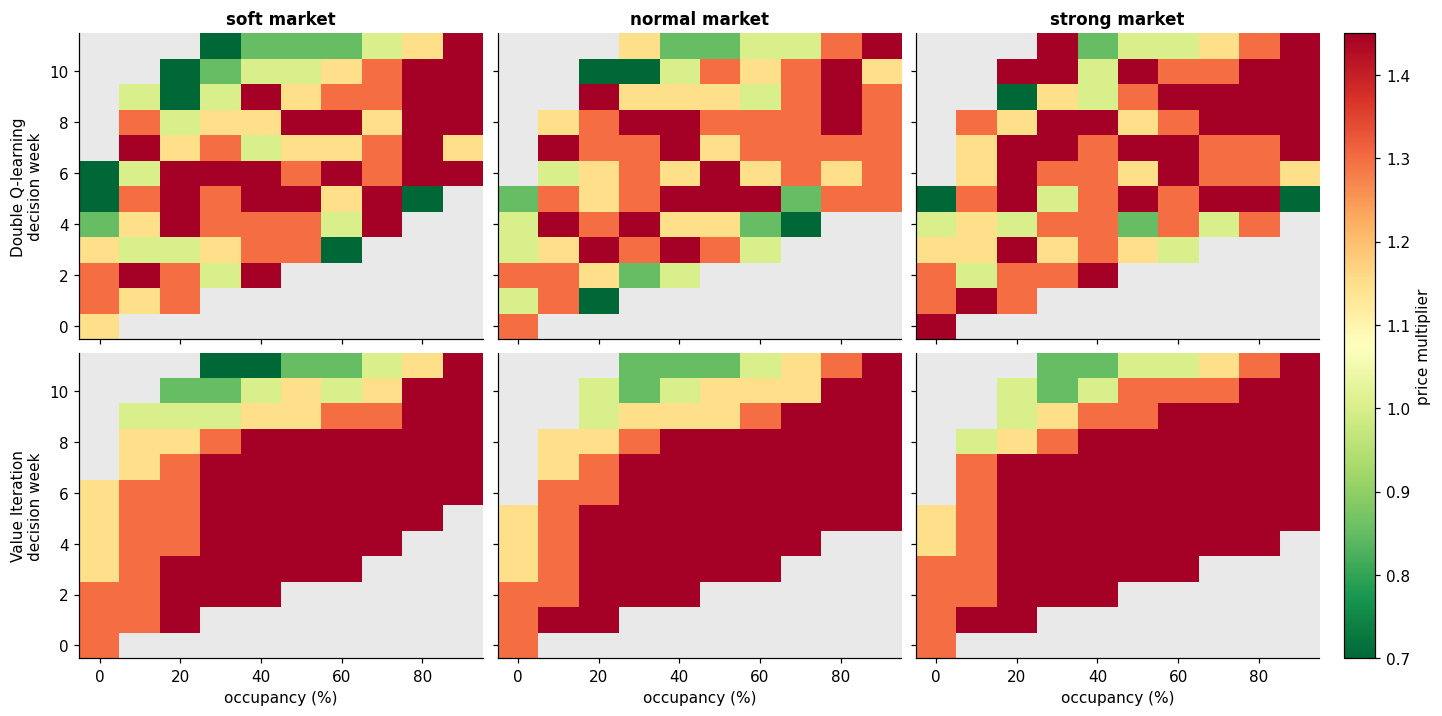

states ever reached in training : 254 of 360
optimal action chosen, unweighted : 41% of states
optimal action chosen, visit-weighted: 59% of decisions taken
value actually given up             : 0.73%


In [8]:
import matplotlib as mpl
from plotting import UNVISITED

learned = policy_table(Q)
visited = Q.any(axis=3)                     # a state whose Q row is all zero was never updated
pi_star = pi_star_full

cmap = mpl.colormaps["RdYlGn_r"].with_extremes(bad=UNVISITED)
fig, axes = plt.subplots(2, N_REGIMES, figsize=(13, 6.4), sharex=True, sharey=True)
for g in range(N_REGIMES):
    mask = ~visited[week_rows, :, g]
    panels = [
        (np.ma.masked_where(mask, MULTIPLIERS[learned[week_rows, :, g]]), "Double Q-learning"),
        (np.ma.masked_where(mask, MULTIPLIERS[pi_star[:, occ_centres, g]]), "Value Iteration"),
    ]
    for row, (grid, label) in enumerate(panels):
        ax = axes[row, g]
        im = ax.imshow(grid, aspect="auto", cmap=cmap, origin="lower",
                       vmin=MULTIPLIERS.min(), vmax=MULTIPLIERS.max())
        ax.set(xticks=range(0, N_OCC_BINS, 2),
               xticklabels=[f"{10 * b}" for b in range(0, N_OCC_BINS, 2)])
        ax.grid(False)
        if row == 0:
            ax.set_title(f"{REGIME_NAMES[g]} market")
        if g == 0:
            ax.set_ylabel(f"{label}\ndecision week")
        if row == 1:
            ax.set_xlabel("occupancy (%)")
fig.colorbar(im, ax=axes, label="price multiplier", pad=0.02)
save_fig("05_learned_policy")
plt.show()

# How often does the learned policy choose the optimal action - counted per state,
# and again weighted by how often that state is actually visited under the policy?
visits = np.zeros((HORIZON, N_OCC_BINS, N_REGIMES))
env.set_common_randoms(None, None)
env.rng = np.random.default_rng(4242)
for _ in range(3000):
    state = env.reset()
    done = False
    while not done:
        wr, occ, reg = state
        visits[HORIZON - wr, occ, reg] += 1
        state, _, done, _ = env.step(int(np.argmax(Q[wr, occ, reg])))

match = learned[week_rows, :, :] == pi_star[:, occ_centres, :]
reachable = visited[week_rows]

print(f"states ever reached in training : {reachable.sum()} of {reachable.size}")
print(f"optimal action chosen, unweighted : {100 * match[reachable].mean():.0f}% of states")
print(f"optimal action chosen, visit-weighted: "
      f"{100 * (match * visits).sum() / visits.sum():.0f}% of decisions taken")
print(f"value actually given up             : {100 * (1 - exact_value / V_STAR):.2f}%")

In [9]:
np.save(RESULTS / "q_table.npy", Q)
np.save(RESULTS / "q_history.npy", np.array([r["history"] for r in runs]))
joblib.dump({"seed_values": finals, "exact_value": exact_value, "ablation": ablation},
            RESULTS / "q_learning_summary.joblib")
print("saved q_table.npy, q_history.npy, q_learning_summary.joblib")

saved q_table.npy, q_history.npy, q_learning_summary.joblib
